In [18]:
# Data processing
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [7]:

df = pd.read_csv("student_performance_dataset.csv")

df.head()



,student_id,absences,study_hours_per_week,math_score,english_score,assignment_average,behavior_score,success
0,1,20,3,33,65,55,2,0
1,2,4,3,99,41,77,4,1
2,3,1,0,41,57,54,5,0
3,4,19,0,55,99,66,2,0
4,5,14,18,65,30,88,2,1


In [10]:
data.describe()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   student_id            100 non-null    int64
 1   absences              100 non-null    int64
 2   study_hours_per_week  100 non-null    int64
 3   math_score            100 non-null    int64
 4   english_score         100 non-null    int64
 5   assignment_average    100 non-null    int64
 6   behavior_score        100 non-null    int64
 7   success               100 non-null    int64
dtypes: int64(8)
memory usage: 6.4 KB


In [40]:
# Variables explicatives
X = df.drop(columns=["student_id", "success"])

# Variable cible
y = df["success"]

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)

In [44]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [45]:
svm_model = SVC()
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

In [46]:
print("\n===== Logistic Regression =====")
print(classification_report(y_test, log_pred))

print("\n===== Random Forest =====")
print(classification_report(y_test, rf_pred))

print("\n===== SVM =====")
print(classification_report(y_test, svm_pred))


===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         9
           1       1.00      0.73      0.84        11

    accuracy                           0.85        20
   macro avg       0.88      0.86      0.85        20
weighted avg       0.89      0.85      0.85        20


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.82      1.00      0.90         9
           1       1.00      0.82      0.90        11

    accuracy                           0.90        20
   macro avg       0.91      0.91      0.90        20
weighted avg       0.92      0.90      0.90        20


===== SVM =====
              precision    recall  f1-score   support

           0       0.64      1.00      0.78         9
           1       1.00      0.55      0.71        11

    accuracy                           0.75        20
   macro avg       0.82      0.77      0.74        

Models: ['Logistic Regression', 'Random Forest', 'SVM']
Accuracies: [0.85, 0.9, 0.75]


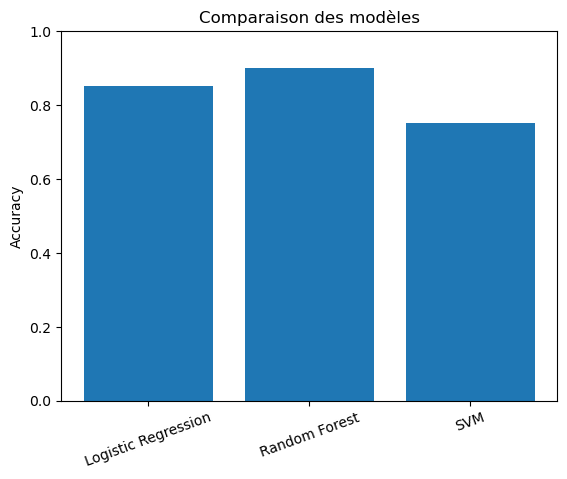

In [47]:
# Calcul des accuracies
log_acc = accuracy_score(y_test, log_pred)
rf_acc = accuracy_score(y_test, rf_pred)
svm_acc = accuracy_score(y_test, svm_pred)

# Mettre dans des listes
models = ["Logistic Regression", "Random Forest", "SVM"]
accuracies = [log_acc, rf_acc, svm_acc]

# Vérification (important)
print("Models:", models)
print("Accuracies:", accuracies)

# Graphique
plt.figure()
plt.bar(models, accuracies)
plt.title("Comparaison des modèles")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

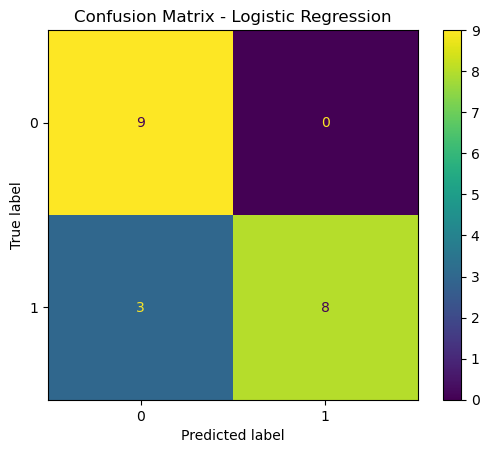

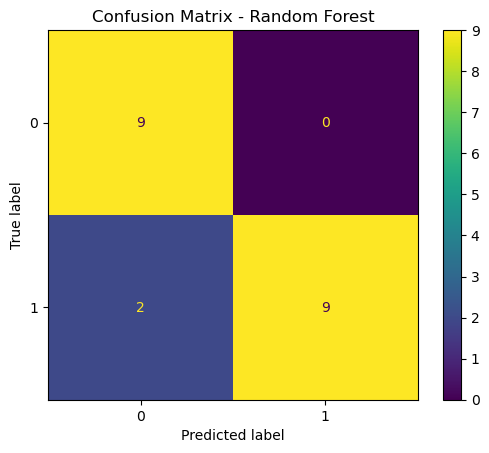

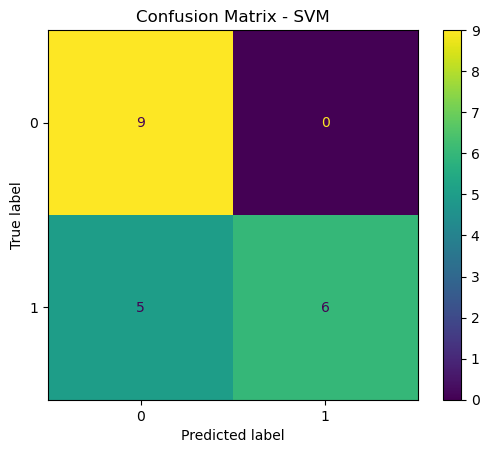

In [32]:
# Logistic Regression
ConfusionMatrixDisplay.from_predictions(y_test, log_pred)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# Random Forest
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.title("Confusion Matrix - Random Forest")
plt.show()

# SVM
ConfusionMatrixDisplay.from_predictions(y_test, svm_pred)
plt.title("Confusion Matrix - SVM")
plt.show()